2026-03-06 09:59:48.416497: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772791188.614705      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772791188.670545      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772791189.133903      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772791189.133959      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772791189.133962      17 computation_placer.cc:177] computation placer alr

Prediction: English Ivy (Hedera helix)
Confidence: 0.03151177614927292


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

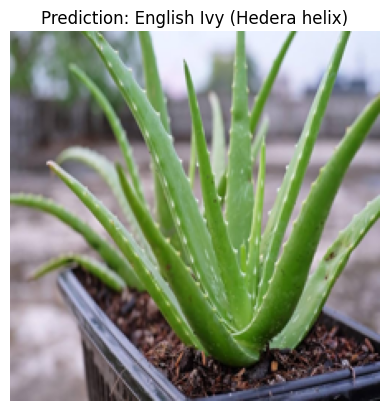

In [1]:
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt

IMG_SIZE = (224,224)

model_path = "/kaggle/input/datasets/swayampani/plant-tflite/plant_model_quantized.tflite"
label_path = "/kaggle/input/datasets/swayampani/plant-tflite/plant_labels.txt"
image_path = "/kaggle/input/datasets/swayampani/plant-tflite/aloe_vera.jpeg"

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path=model_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load labels
with open(label_path) as f:
    labels = [line.strip() for line in f.readlines()]

# Load and preprocess image
img = Image.open(image_path).convert("RGB")
img = img.resize(IMG_SIZE)

img_array = np.array(img).astype("float32") / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Run inference
interpreter.set_tensor(input_details[0]['index'], img_array)
interpreter.invoke()

output = interpreter.get_tensor(output_details[0]['index'])[0]

pred_index = np.argmax(output)

print("Prediction:", labels[pred_index])
print("Confidence:", float(output[pred_index]))

# Show image
plt.imshow(img)
plt.title(f"Prediction: {labels[pred_index]}")
plt.axis("off")